# Sentiment Analysis with pre-trained models and fine-tuning methods

Python version == 3.12.13

| Property | BERT-based models |
|---|---|
| Architecture | Encoder-only (discriminative) |
| Task fit for sentiment | Direct (classification head) |
| Inference speed | faster than ED models (single forward pass) |
| Fine-tuning efficiency | Lower — ideal for local machines |

---

## BERT-based model options

### 1. `bert-base-multilingual-cased` (mBERT)
 - **Params:** ~177M | **Languages:** 104
 - WordPiece tokenizer

### 2. `distilbert-base-multilingual-cased`
 - **Params:** ~135M | **Languages:** 104
 - Kafka Streaming

### 3. `xlm-roberta-base` (XLM-RoBERTa)
 - **Params:** ~278M | **Languages:** 100 
 - SentencePiece tokenizer 

## Import necessary packages and configurations

In [1]:
# Necessary imports
import os
import time
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel,
)
import evaluate

from langdetect import detect, LangDetectException

print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}") # My mac uses mps
print(f"CUDA available: {torch.cuda.is_available()}") # CUDA is added just in case

PyTorch version: 2.2.2
MPS available: True
CUDA available: False


In [2]:
DATA_PATH = "/Users/julianyoo/Downloads/GitHub/machine_learning_project/synthetic_social_media_data.csv" # This to be modified when the cleaned dataset got pushed

# Baseline model for fine-tning
BASE_MODEL_NAME = "xlm-roberta-base"

# Stream model for Kafka
STREAM_MODEL_NAME  = "distilbert-base-multilingual-cased"

# Model names
MODELS = {
    "xlm-roberta"  : "xlm-roberta-base",
    "mbert"        : "bert-base-multilingual-cased",
    "distilbert-ml": "distilbert-base-multilingual-cased",
}

# Training Configuration
MAX_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 20
WEIGHT_DECAY = 0.01
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
TEST_SIZE = 0.15
VAL_SIZE = 0.10
SEED = 42

# LoRA Configuration
LORA_R = 16 # LoRA Rank 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.1
LORA_LR = 3e-4

# DistilBERT uses different attention layer names for LoRA
LORA_TARGETS = {
    "xlm-roberta"  : ["query", "value"],
    "mbert"        : ["query", "value"],
    "distilbert-ml": ["q_lin", "v_lin"],
}

# Output dir
FULL_FT_DIR = "./outputs/bert_fullft"
LORA_FT_DIR = "./outputs/bert_lora"
STREAM_MODEL_DIR = "./outputs/stream_model"
os.makedirs("./outputs", exist_ok=True)

# Device choice
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Active device: {DEVICE}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Active device: mps


## Data load and pre-processing

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

Raw shape: (2000, 10)
Columns: ['Post ID', 'Post Content', 'Sentiment Label', 'Number of Likes', 'Number of Shares', 'Number of Comments', 'User Follower Count', 'Post Date and Time', 'Post Type', 'Language']


,Post ID,Post Content,Sentiment Label,Number of Likes,Number of Shares,Number of Comments,User Follower Count,Post Date and Time,Post Type,Language
0,aa391375-7355-44b7-bcbf-97fb4e5a2ba3,Word who nor center everything better politica...,Neutral,157,243,64,4921,2024-01-10 00:14:21,video,fr
1,1c9ec98d-437a-48d9-9cba-bd5ad853c59a,Begin administration population good president...,Positive,166,49,121,612,2024-02-03 00:20:11,image,es
2,170e5b5b-1d9a-4d02-a957-93c4dbb18908,Thousand total sign. Agree product relationshi...,Positive,185,224,179,9441,2024-07-25 14:20:23,video,de


In [4]:
df = df_raw.rename(columns={
    "Post Content"   : "Text",
    "Sentiment Label": "Sentiment",
})

cols_to_drop = ["Post ID", "Number of Likes", "Number of Shares",
             "Number of Comments", "User Follower Count",
             "Post Date and Time", "Post Type"]

df =  df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Standardise the text
df["Text"] = df["Text"].astype(str).str.strip()
df["Sentiment"] = df["Sentiment"].astype(str).str.lower().str.strip()
df = df.dropna(subset=["Text", "Sentiment"])
df = df[df["Text"].str.len() > 0].reset_index(drop=True)

print(f"\nCleaned shape : {df.shape}")
print(f"\nSentiment distribution:")
print(df["Sentiment"].value_counts())
df.head(3)


Cleaned shape : (2000, 3)

Sentiment distribution:
Sentiment
neutral     682
negative    675
positive    643
Name: count, dtype: int64


,Text,Sentiment,Language
0,Word who nor center everything better politica...,neutral,fr
1,Begin administration population good president...,positive,es
2,Thousand total sign. Agree product relationshi...,positive,de


Since the dataset already contains language codes, skip langdetect

In [5]:
print("Language distribution (from dataset metadata):")
print(df["Language"].value_counts())

Language distribution (from dataset metadata):
Language
es    431
de    424
en    421
fr    370
zh    354
Name: count, dtype: int64


Language
es    431
de    424
en    421
fr    370
zh    354
Name: count, dtype: int64


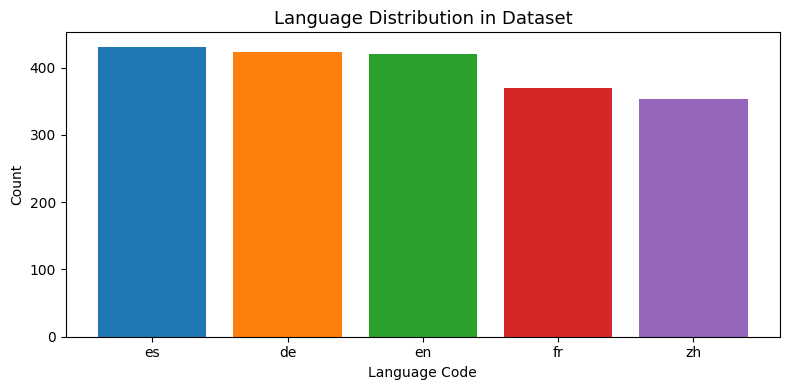

In [6]:
# Multi-language distribution
lang_dist = df["Language"].value_counts()
print(lang_dist)
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lang_dist.index, lang_dist.values,
       color=sns.color_palette("tab10", len(lang_dist)))
ax.set_title("Language Distribution in Dataset", fontsize=13)
ax.set_xlabel("Language Code")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Number of classes: 3
label2id mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


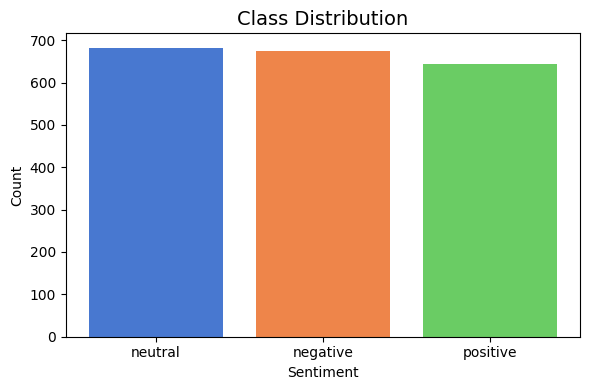

In [7]:
# Encode the labels
unique_labels = sorted(df["Sentiment"].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_LABELS = len(unique_labels)

df["label"] = df["Sentiment"].map(label2id)
 
print(f"Number of classes: {NUM_LABELS}")
print(f"label2id mapping: {label2id}")

fig, ax = plt.subplots(figsize=(6, 4))
counts = df["Sentiment"].value_counts()
ax.bar(counts.index, counts.values,
       color=sns.color_palette("muted", len(counts)))
ax.set_title("Class Distribution", fontsize=14)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [8]:
# Stratified TTS the dataset
train_val_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df["label"], random_state=SEED)
val_ratio_adjusted = VAL_SIZE / (1 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_ratio_adjusted,
    stratify=train_val_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
 
print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)}   samples")
print(f"Test: {len(test_df)}  samples")

Train: 1499 samples
Val: 201   samples
Test: 300  samples


In [9]:
# Change into HF DatasetDict
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["Text", "label", "Language"]], preserve_index=False),
    "val": Dataset.from_pandas(val_df[["Text", "label", "Language"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["Text", "label", "Language"]], preserve_index=False)
})
print(f"\nDatasetDict: {dataset}")


DatasetDict: DatasetDict({
    train: Dataset({
        features: ['Text', 'label', 'Language'],
        num_rows: 1499
    })
    val: Dataset({
        features: ['Text', 'label', 'Language'],
        num_rows: 201
    })
    test: Dataset({
        features: ['Text', 'label', 'Language'],
        num_rows: 300
    })
})


## Tokenise
RoBERTa uses SentencePiece BPE and BERT uses WordPiece.


In [10]:
# Load Tokeniser
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

sample_text = "The product launch was absolutely amazing! #BrandName"
tokens = tokenizer.tokenize(sample_text)
print(f"Sample text: {sample_text}")
print(f"Tokens: {tokens}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Max length: {tokenizer.model_max_length}")

Sample text: The product launch was absolutely amazing! #BrandName
Tokens: ['▁The', '▁product', '▁launch', '▁was', '▁absolutely', '▁amazing', '!', '▁#', 'B', 'rand', 'Name']
Vocab size: 250,002
Max length: 512


In [11]:
# Tokenzed dataset
def make_tokenized_dataset(model_name: str) -> tuple[DatasetDict, AutoTokenizer]:
    """
    Build a fresh tokenized DatasetDict for any BERT-family model.
    Thisshould be called per model since each has its own tokenizer.
    """
    tok = AutoTokenizer.from_pretrained(model_name)
 
    ds = DatasetDict({
        "train": Dataset.from_pandas(train_df[["Text", "label"]], preserve_index=False),
        "val": Dataset.from_pandas(val_df[["Text", "label"]], preserve_index=False),
        "test" : Dataset.from_pandas(test_df[["Text", "label"]], preserve_index=False),
    })
 
    def tokenize_fn(batch):
        return tok(
            batch["Text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors=None,
        )
 
    tokenized_ds = ds.map(
        tokenize_fn,
        batched=True,
        batch_size=512,
        remove_columns=["Text"],
        desc=f"Tokenising [{model_name.split('/')[-1]}]",
    )
    tokenized_ds.set_format(
        type="torch", columns=["input_ids", "attention_mask", "label"]
    )
    return tokenized_ds, tok

tokenized, _ = make_tokenized_dataset(BASE_MODEL_NAME)
 
print(f"\nTokenized features : {tokenized['train'].features}")
print(f"Train sample shape : {tokenized['train']['input_ids'][0].shape}")

Tokenising [xlm-roberta-base]:   0%|          | 0/1499 [00:00<?, ? examples/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Tokenising [xlm-roberta-base]: 100%|██████████| 300/300 [00:00<00:00, 18119.25 examples/s]


Tokenized features : {'label': Value(dtype='int64', id=None), 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}
Train sample shape : torch.Size([128])


In [12]:
# For each language evaluation
test_with_lang = test_df.copy()

## Models
BERT-based models use linear classification head on top of [CLS] token represenation. Not generative.

The models output logit vectors of size num_labels, softmaxed into class probabilities.

In [13]:
# Load model with classification head
def load_base_model(model_name:str=BASE_MODEL_NAME) -> AutoModelForSequenceClassification:
    """
    This is to load XLM-RoBERTa with a fresh classification head.
    'num_labels', 'id2label', 'label2id' params are attached to the model config
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )
    return model.to(DEVICE)

base_model = load_base_model()

def count_params(model) -> str:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return (
        f"  Trainable: {trainable:>12,}\n"
        f"  Total: {total:>12,}\n"
        f"  Rate(%): {100 * trainable / total:.2f}%"
    )

print(count_params(base_model))

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Trainable:  278,045,955
  Total:  278,045,955
  Rate(%): 100.00%


In [14]:
# Accuracy metrics functions
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")
 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}

In [15]:
# Class weight calculation
# Inversely proportional to class frequency.
# Formula: w_c = total_samples / (num_classes × count_c)
label_counts  = train_df["label"].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (NUM_LABELS * label_counts[i]) for i in range(NUM_LABELS)],
    dtype=torch.float32,
).to(DEVICE)
 
print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"    {id2label[i]:<12} : {w:.4f}")

Class weights:
    negative     : 0.9875
    neutral      : 0.9778
    positive     : 1.0367


## N-Shot Inferences

### Zero-Shot on Baseline
Evaluate the pre-trained XLM-RoBERTa without any fine-tuning

In [16]:
base_model = load_base_model()
print(count_params(base_model))

def zero_shot_inference(model, tokenizer_, texts: list, device=DEVICE) -> list:
    model.eval()
    preds = []
    with torch.no_grad():
        for text in texts:
            enc = tokenizer_(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding=True).to(device)
            logits = model(**enc).logits
            pred_id = logits.argmax(dim=-1).item()
            preds.append(id2label[pred_id])
    return preds

# Test with a sample
demo = min(10, len(test_df))
demo_texts = test_df["Text"].tolist()[:demo]
demo_labels = test_df["Sentiment"].tolist()[:demo]
base_preds = zero_shot_inference(base_model, tokenizer, demo_texts)

print("Zero-shot Baseline - XLM-RoBERTa")
for i, (text, true_lbl, pred_lbl) in enumerate(zip(demo_texts, demo_labels, base_preds)):
    status = "True" if pred_lbl == true_lbl else "False"
    print(f"[{i+1:02d}] {status} | True: {true_lbl:<12} | Pred: {pred_lbl:<12}")
    print(f"        Text: {text[:80]}" if len(text) > 80 else f"      Text: {text}")
    print()

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Trainable:  278,045,955
  Total:  278,045,955
  Rate(%): 100.00%
Zero-shot Baseline - XLM-RoBERTa
[01] False | True: neutral      | Pred: negative    
        Text: Country term policy value something identify friend.
Suddenly wife ok run how. A

[02] False | True: neutral      | Pred: negative    
        Text: Training north sport American. Area mention word source week the. Somebody admin

[03] False | True: positive     | Pred: negative    
        Text: Recently well matter world. Themselves police they total cultural.
Risk move spr

[04] False | True: neutral      | Pred: negative    
        Text: Move day defense religious mission. Great think have culture important yard.
Avo

[05] True | True: negative     | Pred: negative    
        Text: Suffer day better scientist partner evidence explain. Teacher relate large parti

[06] False | True: positive     | Pred: negative    
        Text: Together commercial force president job may.
Explain federal challenge business.

[07] Fa

### Few-shot inferences

In [17]:
# Extracting CLS embeddings from BERT
def extract_cls_embeddings(model, tokenizer_, texts:list, device=DEVICE, batch_size:int=32) -> torch.Tensor:
    """
    Extrac [CLS] embeddings from the last hidden state. # Shape: (N, hidden_dim)
    """
    model.eval()
    all_embeddings = []

    # Access transformer
    if hasattr(model, "roberta"):
        encoder = model.roberta
    elif hasattr(model, "bert"):
        encoder = model.bert
    elif hasattr(model, "distilbert"):
        encoder = model.distilbert
    else:
        raise ValueError("Unknown model architecture.")

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i: i+batch_size]
            enc = tokenizer_(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH).to(device)
            outputs = encoder(**enc)
            # [CLS] token is position 0 in the seq
            cls_emb = outputs.last_hidden_state[:, 0, :] # (batch, hidden)
            all_embeddings.append(cls_emb.cpu())

    return torch.cat(all_embeddings, dim=0)

In [18]:
# Classifiers for k-shot settings
def build_prototypes(model, tokenizer_, support_df:pd.DataFrame, k_shots:int) -> tuple[torch.Tensor, list]:
    """
    N samples per class from support_df, extract embeddings, and compute per-class centroids.

    Returns:
    prototypes: Tensor (num_classes, hidden_dim) - class centroids
    proto_labels: list of label strings in prototype order
    """
    class_embeddings = {}
    for label_str in unique_labels:
        class_rows = support_df[support_df["Sentiment"] == label_str]
        n_sample   = min(k_shots, len(class_rows))
        sample     = class_rows.sample(n=n_sample, random_state=SEED)
        embs       = extract_cls_embeddings(model, tokenizer_, sample["Text"].tolist())
        class_embeddings[label_str] = embs.mean(dim=0)  # Centroid

    proto_labels = list(class_embeddings.keys())
    prototypes   = torch.stack([class_embeddings[l] for l in proto_labels])
    return prototypes, proto_labels

# Predict the class from the query texts by cosine similarity
def prototype_predict(model, tokenizer_, query_texts: list, prototypes: torch.Tensor, proto_labels: list) -> list:
    query_embs = extract_cls_embeddings(model, tokenizer_, query_texts)  # (N, H)

    # Normalise both query and prototypes for cosine sim
    q_norm = torch.nn.functional.normalize(query_embs, dim=-1)
    p_norm = torch.nn.functional.normalize(prototypes, dim=-1)

    similarities = q_norm @ p_norm.T # (N, num_classes)
    pred_indicies = similarities.argmax(dim=-1).tolist()
    return [proto_labels[i] for i in pred_indicies]

In [19]:
few_shot_results = {}
query_texts = test_df["Text"].tolist()[:50] # Query set
query_labels = test_df["Sentiment"].tolist()[:50]

# Support_df is the copy of train data
support_df = train_df.copy()

for k in [1, 3, 5]:
    prototypes, proto_labels = build_prototypes(base_model, tokenizer, support_df, k_shots=k)
    preds = prototype_predict(base_model, tokenizer, query_texts, prototypes, proto_labels)
    acc   = accuracy_score(query_labels, preds)
    few_shot_results[f"{k}-shot"] = acc

    print(f"  {k}-SHOT PROTOTYPE INFERENCE  (Accuracy: {acc:.4f})")
    for j in range(min(5, len(query_texts))):
        status = "True" if preds[j] == query_labels[j] else "False"
        print(f"    [{j+1}] {status} True: {query_labels[j]:<12} | Pred: {preds[j]:<12}")
        print(f"        Text: {query_texts[j][:80]}")
    print()

print("\nFew-Shot Summary:")
for k_str, acc in few_shot_results.items():
    print(f"  {k_str}: {acc:.4f} accuracy")

  1-SHOT PROTOTYPE INFERENCE  (Accuracy: 0.3600)
    [1] False True: neutral      | Pred: positive    
        Text: Country term policy value something identify friend.
Suddenly wife ok run how. A
    [2] False True: neutral      | Pred: positive    
        Text: Training north sport American. Area mention word source week the. Somebody admin
    [3] False True: positive     | Pred: neutral     
        Text: Recently well matter world. Themselves police they total cultural.
Risk move spr
    [4] False True: neutral      | Pred: positive    
        Text: Move day defense religious mission. Great think have culture important yard.
Avo
    [5] False True: negative     | Pred: positive    
        Text: Suffer day better scientist partner evidence explain. Teacher relate large parti

  3-SHOT PROTOTYPE INFERENCE  (Accuracy: 0.2800)
    [1] False True: neutral      | Pred: positive    
        Text: Country term policy value something identify friend.
Suddenly wife ok run how. A
    [2]

1 shot gives us the best accuracy but 0.36 ...

## Full fine-tuning

Instead of a general Trainer, FocalLossTrainer was used. ((1 - pt)^γ × CE). This is for the model is confidently predicting "negative" for every sample, `pt` is high and `(1 - pt)^2` shrinks the loss nearly to zero. The model gets nearly no reward for the easy collapse strategy.

In [20]:
class WeightedTrainer(Trainer):
    """
    CrossEntropyLoss with inverse-frequency class weights.
    """
    def __init__(self, *args, class_weights: torch.Tensor, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
 
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [21]:
class FocalLossTrainer(Trainer):
    """
    Focal Loss with optional class weights.
    gamma=2 down-weights easy/confident predictions so the model
    cannot exploit single-class collapse to minimise loss.
    """
    def __init__(self, *args, gamma: float = 2.0,
                 class_weights: torch.Tensor = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma         = gamma
        self.class_weights = class_weights
 
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
 
        ce_fn   = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
            if self.class_weights is not None else None,
            reduction="none",
        )
        ce_loss = ce_fn(logits, labels)
        pt      = torch.exp(-ce_loss)
        loss    = ((1 - pt) ** self.gamma * ce_loss).mean()
 
        return (loss, outputs) if return_outputs else loss

In [26]:
# Full fine-tuning arguments (config) for MPS (Apple Silicon)
def run_full_finetune(model_key: str, model_name: str, tokenized_ds: DatasetDict) -> dict:
    print(f"    Full fine-tuning: {model_key} ({model_name})")

    model = load_base_model(model_name)
    out_dir = f"./outputs/{model_key}_fullft"
    os.makedirs(out_dir, exist_ok=True)

    print(count_params(model))

    args = TrainingArguments(
        output_dir = out_dir,
        num_train_epochs = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size = BATCH_SIZE * 2,
        learning_rate = LEARNING_RATE,
        weight_decay = WEIGHT_DECAY,
        warmup_ratio = WARMUP_RATIO,
        max_grad_norm = 1.0,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        load_best_model_at_end = True,
        metric_for_best_model = "f1_macro",
        greater_is_better = True,
        logging_steps = 20,
        report_to = "none", # Disable wandb/tensorboard - can use wandb
        seed = SEED,
        fp16 = False, # MPS does not support fp16 training
        bf16 = False, # bfloat16 not supported on MPS trainer
        dataloader_num_workers = 0, # Required for MPS stability
        push_to_hub = False
    )

    trainer = FocalLossTrainer(
        model = model,
        args = args,
        train_dataset = tokenized["train"],
        eval_dataset = tokenized["val"],
        compute_metrics = compute_metrics,
        gamma = 2.0,
        class_weights = class_weights,
        callbacks = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    print(f"    Training time : {time.time() - t0:.0f}s")

    trainer.save_model(f"{out_dir}/best")
 
    test_res = trainer.evaluate(tokenized_ds["test"])
    pred_out = trainer.predict(tokenized_ds["test"])
    pred_ids = np.argmax(pred_out.predictions, axis=-1)
    true_ids = pred_out.label_ids

    print(f"\n  Test Accuracy : {test_res['eval_accuracy']:.4f}")
    print(f"  Test F1-Macro : {test_res['eval_f1_macro']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(true_ids, pred_ids, target_names=unique_labels))
 
    return {
        "model_key"   : model_key,
        "method"      : "Full FT",
        "test_results": test_res,
        "pred_ids"    : pred_ids,
        "true_ids"    : true_ids,
    }

## PEFT/ LoRA Fine-tuning
LoRA(Low-Rank Adaptation) freezes the pre-trained weights and injects quite smaller trainable rank-decomposition
matrices into the attention layers.

Class weights (WeightTrainer) was used. Since LoRA has a fewer params, focal loss might be aggressive.

In [27]:
def run_lora_finetune(model_key: str, model_name: str, tokenized_ds: DatasetDict) -> dict:
    print(f"    LoRA Fine-tuning: {model_key} ({model_name})")

    base = load_base_model(model_name)
    out_dir = f"./outputs/{model_key}_lora"
    os.makedirs(out_dir, exist_ok=True)

    cfg = LoraConfig(
        r = LORA_R,
        lora_alpha = LORA_ALPHA,
        target_modules = LORA_TARGETS[model_key],
        lora_dropout = LORA_DROPOUT,
        bias = "none",
        task_type = TaskType.SEQ_CLS, # Sequence classification (not SEQ_2_SEQ)
        inference_mode = False,
    )
    model = get_peft_model(base, cfg)
 
    print(count_params(model))
    model.print_trainable_parameters()

    args = TrainingArguments(
        output_dir = out_dir,
        num_train_epochs = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size = BATCH_SIZE * 2,
        learning_rate = LORA_LR,
        weight_decay = WEIGHT_DECAY,
        warmup_ratio = WARMUP_RATIO,
        max_grad_norm = 1.0,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        load_best_model_at_end = True,
        metric_for_best_model = "f1_macro",
        greater_is_better = True,
        logging_steps = 20,
        report_to = "none",
        seed = SEED,
        fp16 = False,
        bf16 = False,
        dataloader_num_workers = 0,
        push_to_hub = False,
    )

    trainer = WeightedTrainer(
        model = model,
        args = args,
        train_dataset = tokenized_ds["train"],
        eval_dataset = tokenized_ds["val"],
        compute_metrics = compute_metrics,
        class_weights = class_weights,
        callbacks = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    print(f"    Training time : {time.time() - t0:.0f}s")

    model.save_pretrained(f"{out_dir}/adapters")
 
    test_res = trainer.evaluate(tokenized_ds["test"])
    pred_out = trainer.predict(tokenized_ds["test"])
    pred_ids = np.argmax(pred_out.predictions, axis=-1)
    true_ids = pred_out.label_ids

    print(f"\n  Test Accuracy : {test_res['eval_accuracy']:.4f}")
    print(f"    Test F1-Macro : {test_res['eval_f1_macro']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(true_ids, pred_ids, target_names=unique_labels))
 
    return {
        "model_key": model_key,
        "method": "LoRA",
        "test_results": test_res,
        "pred_ids": pred_ids,
        "true_ids": true_ids,
    }

### Comparison of three models

In [28]:
all_results = []
 
for model_key, model_name in MODELS.items():
    print(f"\nMODEL : {model_key.upper()}")
    print(f"    {model_name}")
 
    tokenized_ds, _ = make_tokenized_dataset(model_name)
 
    all_results.append(run_full_finetune(model_key, model_name, tokenized_ds))
    all_results.append(run_lora_finetune(model_key, model_name, tokenized_ds))
 
    if DEVICE.type == "mps":
        torch.mps.empty_cache()


MODEL : XLM-ROBERTA
    xlm-roberta-base


Tokenising [xlm-roberta-base]: 100%|██████████| 300/300 [00:00<00:00, 19388.45 examples/s]
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    Full fine-tuning: xlm-roberta (xlm-roberta-base)
  Trainable:  278,045,955
  Total:  278,045,955
  Rate(%): 100.00%


  1%|          | 20/1880 [00:10<13:24,  2.31it/s] 

{'loss': 0.5096, 'grad_norm': 5.3206048011779785, 'learning_rate': 2.1276595744680853e-06, 'epoch': 0.21}


...

{'eval_loss': 1.5461786985397339, 'eval_accuracy': 0.3482587064676617, 'eval_f1_macro': 0.34763509506366647, 'eval_runtime': 0.6595, 'eval_samples_per_second': 304.784, 'eval_steps_per_second': 10.614, 'epoch': 8.0}


 40%|████      | 752/1880 [01:42<02:34,  7.32it/s]


{'train_runtime': 102.7793, 'train_samples_per_second': 291.693, 'train_steps_per_second': 18.292, 'train_loss': 0.9711530284678682, 'epoch': 8.0}
    Training time : 103s


100%|██████████| 10/10 [00:00<00:00, 11.51it/s]


  Test Accuracy : 0.3067
    Test F1-Macro : 0.3021

  Classification Report:
              precision    recall  f1-score   support

    negative       0.33      0.32      0.32       101
     neutral       0.25      0.20      0.22       102
    positive       0.32      0.41      0.36        97

    accuracy                           0.31       300
   macro avg       0.30      0.31      0.30       300
weighted avg       0.30      0.31      0.30       300



In [29]:
rows = []
for r in all_results:
    tr = r["test_results"]
    rows.append({
        "Model": r["model_key"],
        "Method": r["method"],
        "Accuracy": round(tr["eval_accuracy"], 4),
        "F1-Macro": round(tr["eval_f1_macro"], 4),
        "Loss": round(tr["eval_loss"], 4),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.sort_values("F1-Macro", ascending=False).to_string(index=False))

        Model  Method  Accuracy  F1-Macro   Loss
distilbert-ml    LoRA    0.3067    0.3021 1.3583
        mbert    LoRA    0.3267    0.2597 1.0981
  xlm-roberta Full FT    0.3400    0.1692 0.4897
  xlm-roberta    LoRA    0.3400    0.1692 1.1002
distilbert-ml Full FT    0.3367    0.1679 0.4938
        mbert Full FT    0.3233    0.1637 0.5189


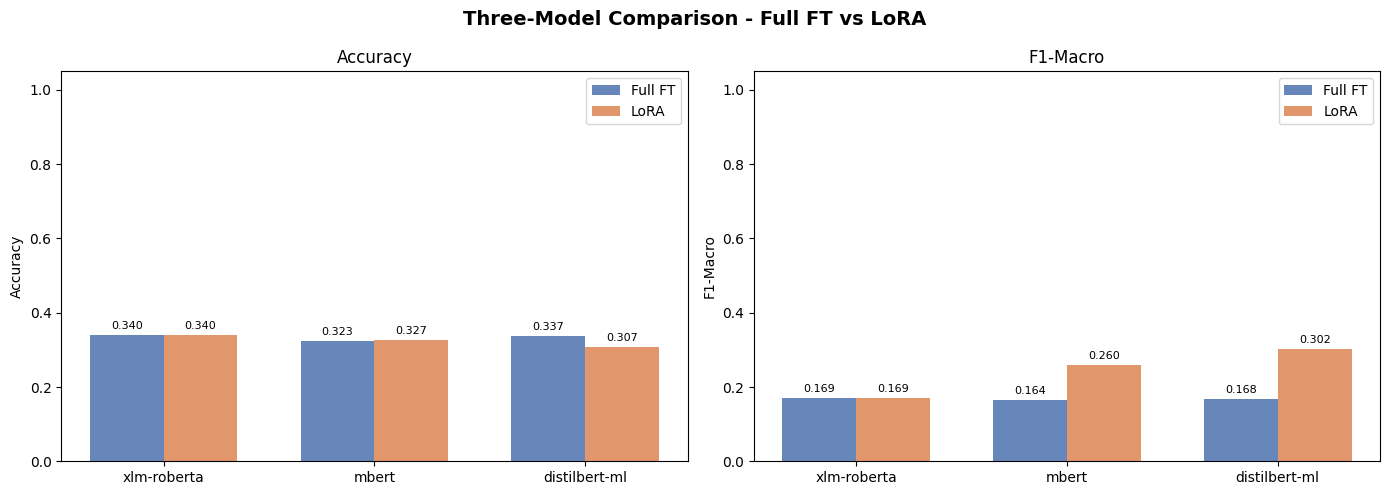

In [30]:
# Bar chart of comparison: Accuracy & F1-Macro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Three-Model Comparison - Full FT vs LoRA", fontsize=14, fontweight="bold")

models = list(MODELS.keys())
x = np.arange(len(models))
width = 0.35
palette = {"Full FT": "#4C72B0", "LoRA": "#DD8452"}

for ax, (metric_col, metric_label) in zip(
    axes,
    [("eval_accuracy", "Accuracy"), ("eval_f1_macro", "F1-Macro")]
):
    for method, offset in zip(["Full FT", "LoRA"], [-width / 2, width / 2]):
        vals = [
            r["test_results"][metric_col]
            for r in all_results if r["method"] == method
        ]
        bars = ax.bar(
            x + offset, vals, width,
            label=method, color=palette[method], alpha=0.85,
        )
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
 
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_label)
    ax.set_ylabel(metric_label)
    ax.legend()

plt.tight_layout()
plt.savefig("./outputs/three_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

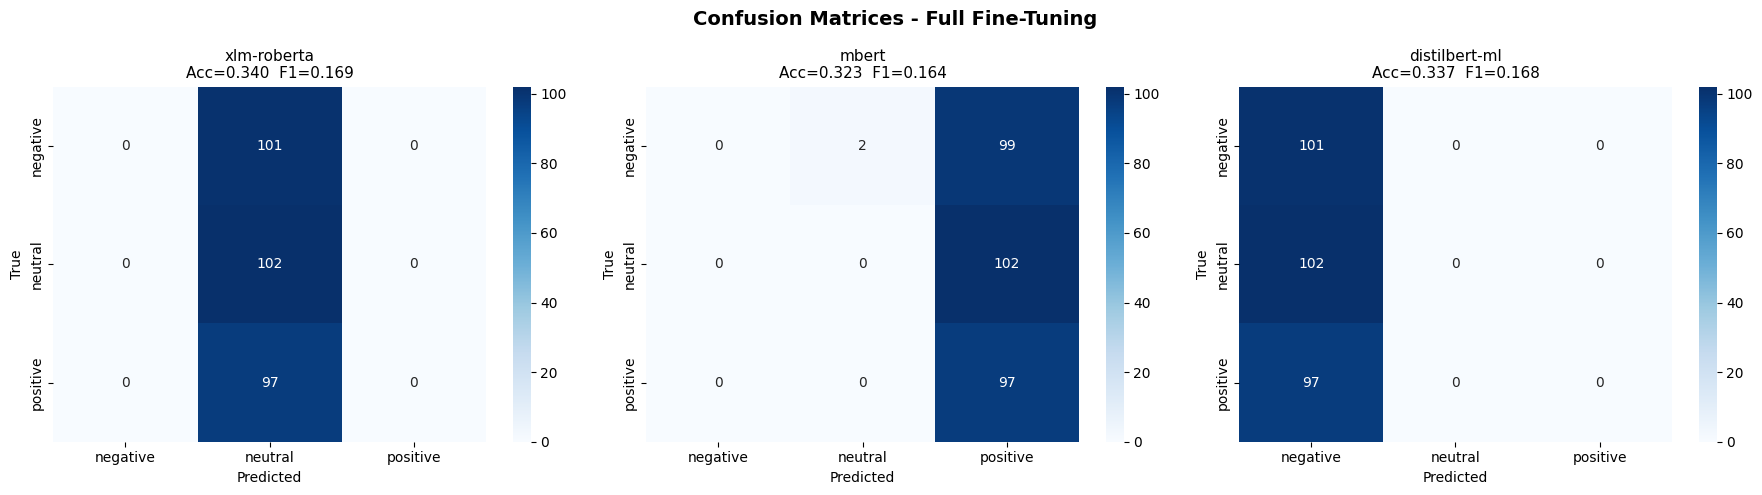

In [31]:
# Confusion Matrix comparison for full ft
full_ft_results = [r for r in all_results if r["method"] == "Full FT"]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices - Full Fine-Tuning", fontsize=14, fontweight="bold")

for ax, r in zip(axes, full_ft_results):
    cm = confusion_matrix(r["true_ids"], r["pred_ids"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=unique_labels, yticklabels=unique_labels, ax=ax,
    )
    acc = r["test_results"]["eval_accuracy"]
    f1  = r["test_results"]["eval_f1_macro"]
    ax.set_title(f"{r['model_key']}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
 
plt.tight_layout()
plt.savefig("./outputs/confusion_matrices_fullft.png", dpi=150, bbox_inches="tight")
plt.show()

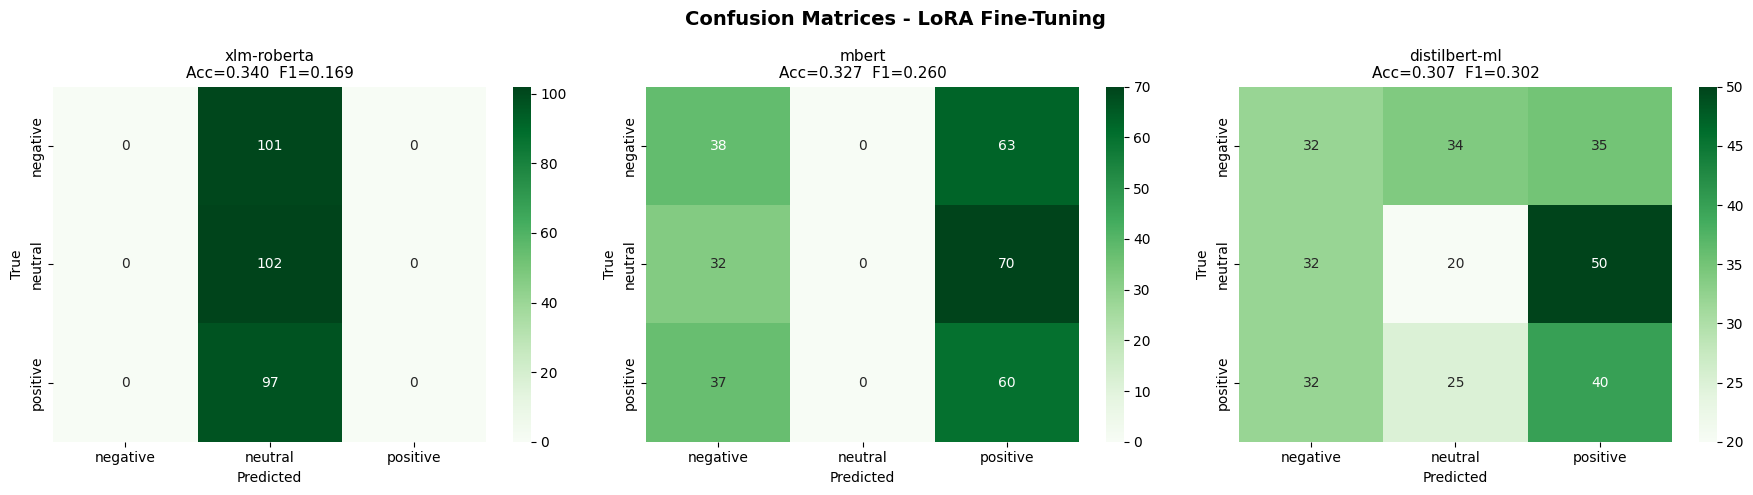

In [32]:
# Confusion Matrix comparison for LoRA
lora_results = [r for r in all_results if r["method"] == "LoRA"]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices - LoRA Fine-Tuning",
             fontsize=14, fontweight="bold")
 
for ax, r in zip(axes, lora_results):
    cm = confusion_matrix(r["true_ids"], r["pred_ids"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=unique_labels, yticklabels=unique_labels, ax=ax,
    )
    acc = r["test_results"]["eval_accuracy"]
    f1  = r["test_results"]["eval_f1_macro"]
    ax.set_title(f"{r['model_key']}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
 
plt.tight_layout()
plt.savefig("./outputs/confusion_matrices_lora.png", dpi=150, bbox_inches="tight")
plt.show()

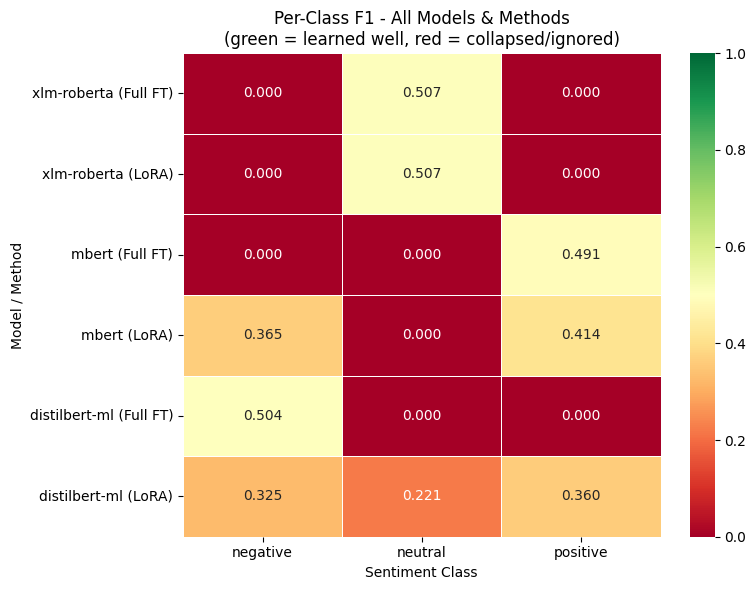

In [33]:
# Per-class F1 heatmap
heatmap_data = {}
for r in all_results:
    key = f"{r['model_key']} ({r['method']})"
    per_class = f1_score(
        r["true_ids"], r["pred_ids"],
        labels=list(range(NUM_LABELS)),
        average=None,
        zero_division=0,
    )
    heatmap_data[key] = per_class
 
heatmap_df = pd.DataFrame(heatmap_data, index=unique_labels).T
 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
)
ax.set_title(
    "Per-Class F1 - All Models & Methods\n"
    "(green = learned well, red = collapsed/ignored)",
    fontsize=12,
)
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Model / Method")
plt.tight_layout()
plt.savefig("./outputs/per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

-> Poor accuracy was caused by the synthetic text from the dataset.

If we want to improve the accuracy, we better re-consider the dataset.

**Model collapsed for full fine-tuning and LoRA methods.**

for the first experiment, there were not much methods added, plain full ft and LoRA with configs. However, the model collapsed becasue the model could not find singals in the text (not due to the class imbalacne).


## Multi-Lingual Support Analysis

Because our dataset already has language labels, this section is not needed

In [34]:
def safe_detect(text: str) -> str:
    """Detect language; return 'unknown' if detection fails."""
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"

# Run on a sample first (full run is in the multilingual section)
sample_detect = df["Text"].sample(min(200, len(df)), random_state=SEED)
detected_langs = sample_detect.apply(safe_detect)

print("Detected language sample distribution:")
print(detected_langs.value_counts().head(10))

Detected language sample distribution:
Text
en    200
Name: count, dtype: int64


Detecting languages (this may take a moment on large datasets)...

Detected 1 unique languages
Top languages:
language
en    2000
Name: count, dtype: int64


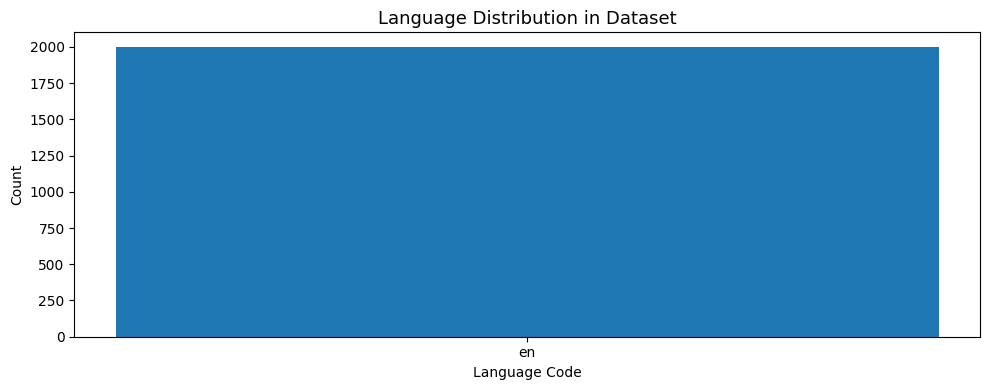

In [35]:
print("Detecting languages (this may take a moment on large datasets)...")
df["language"] = df["Text"].apply(safe_detect)

lang_dist = df["language"].value_counts()
print(f"\nDetected {len(lang_dist)} unique languages")
print("Top languages:")
print(lang_dist.head(15))

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
top_langs = lang_dist.head(10)
ax.bar(top_langs.index, top_langs.values, color=sns.color_palette("tab10", 10))
ax.set_title("Language Distribution in Dataset", fontsize=13)
ax.set_xlabel("Language Code")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Kafka
To be added after analysis of baseline (NLP LSTM based models)